In [3]:
# Getting IBM backend connected

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

import dynamic_broadcast as db
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=200)
np.set_printoptions(precision=3, suppress=True)

service = QiskitRuntimeService(name="mprest1")



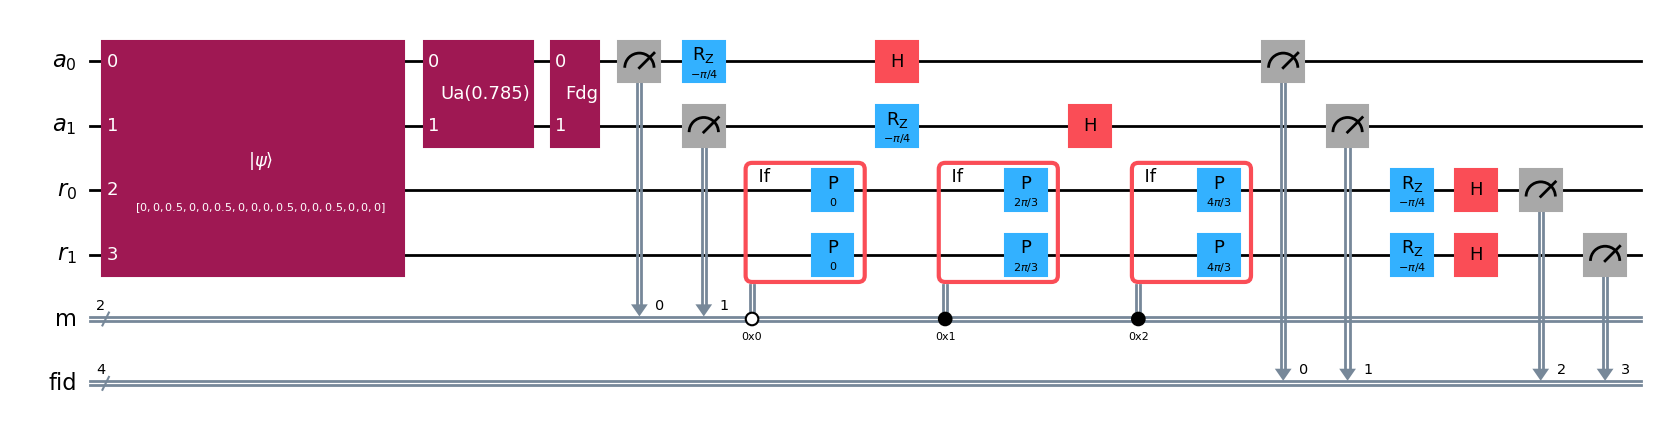

In [4]:
# Testing functions in library
thetas = [np.pi/4]  # The sender phase angles
circuit = db.generate_qiskit_circuit(1, 2, thetas)

circuit, reg_name, phi = db.add_fidelity(circuit, N=4, thetas=thetas)

circuit.draw("mpl")

In [5]:
# Constructing the primitive
backend = service.least_busy(simulator=False, operational=True)
print(f"Backend selected: {backend}")

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)

# isa_circuit.draw("mpl", idle_wires=False)
sampler = Sampler(mode=backend)

param_values = None
job = sampler.run([(isa_circuit, param_values)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")




Backend selected: <IBMBackend('ibm_marrakesh')>
>>> Job ID: d79urahq1efs73d3a1jg
>>> Job Status: QUEUED


In [6]:
# Extracting and displaying the results
pub_result = job.result()[0]
counts = getattr(pub_result.data, reg_name).get_counts()
shots = sum(counts.values())

fidelities = []
for i in range(4):
    p0 = sum(v for bitstr, v in counts.items() if bitstr[::-1][i] == "0") / shots
    fidelities.append(p0)

print(f"Fidelities: {fidelities}")

Fidelities: [0.498291015625, 0.46728515625, 0.531982421875, 0.52392578125]
